In [ ]:
!pip install -q imbalanced-learn --upgrade

In [ ]:
from google.colab import files
uploaded = files.upload()

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

df = pd.read_csv('df_clean.csv')

y = (df['SI'] > 8).astype(int)
X = df.drop(columns=['IC50, mM', 'CC50, mM', 'SI'])

print('Распределение классов')
print(y.value_counts())
print(f'Доля SI > 8: {round(y.mean() * 100, 1)}%')

Распределение классов
SI
0    644
1    357
Name: count, dtype: int64
Доля SI > 8: 35.7%


Классы несбалансированы: около 36% молекул имеют SI > 8. В отличие от задач с медианой, здесь нет автоматического баланса 50/50. Буду учитывать это при обучении, в противном случае модель будет смещена в сторону класса 0.

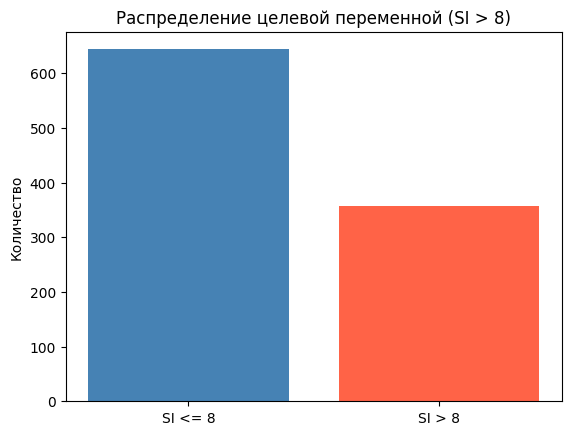

In [2]:
plt.bar(['SI <= 8', 'SI > 8'], y.value_counts().sort_index().values, color=['steelblue', 'tomato'])
plt.title('Распределение целевой переменной (SI > 8)')
plt.ylabel('Количество')
plt.show()

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print('Train:', y_train.value_counts().to_dict())
print('Test:', y_test.value_counts().to_dict())

Train: {0: 515, 1: 285}
Test: {0: 129, 1: 72}


Использую stratify=y, чтобы соотношение классов сохранялось и в train, и в test.

In [4]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print('После SMOTE:', pd.Series(y_train_bal).value_counts().to_dict())

После SMOTE: {0: 515, 1: 515}


SMOTE генерирует синтетические примеры миноритарного класса. Применяю только на train, тест не трогаю — иначе оценка метрик будет завышена.

In [5]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_bal, y_train_bal)
pred = lr.predict(X_test)
prob = lr.predict_proba(X_test)[:, 1]
print('LogisticRegression  Accuracy:', round(accuracy_score(y_test, pred), 3),
      ' F1:', round(f1_score(y_test, pred), 3),
      ' ROC-AUC:', round(roc_auc_score(y_test, prob), 3))

LogisticRegression  Accuracy: 0.642  F1: 0.0  ROC-AUC: 0.635


In [6]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()
knn.fit(X_train_bal, y_train_bal)
pred = knn.predict(X_test)
prob = knn.predict_proba(X_test)[:, 1]
print('KNN                 Accuracy:', round(accuracy_score(y_test, pred), 3),
      ' F1:', round(f1_score(y_test, pred), 3),
      ' ROC-AUC:', round(roc_auc_score(y_test, prob), 3))

KNN                 Accuracy: 0.652  F1: 0.551  ROC-AUC: 0.659


In [7]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_bal, y_train_bal)
pred = rf.predict(X_test)
prob = rf.predict_proba(X_test)[:, 1]
print('RandomForest        Accuracy:', round(accuracy_score(y_test, pred), 3),
      ' F1:', round(f1_score(y_test, pred), 3),
      ' ROC-AUC:', round(roc_auc_score(y_test, prob), 3))

RandomForest        Accuracy: 0.682  F1: 0.556  ROC-AUC: 0.739


In [8]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train_bal, y_train_bal)
pred = gb.predict(X_test)
prob = gb.predict_proba(X_test)[:, 1]
print('GradientBoosting    Accuracy:', round(accuracy_score(y_test, pred), 3),
      ' F1:', round(f1_score(y_test, pred), 3),
      ' ROC-AUC:', round(roc_auc_score(y_test, prob), 3))

GradientBoosting    Accuracy: 0.692  F1: 0.592  ROC-AUC: 0.744


In [9]:
from xgboost import XGBClassifier

xgb = XGBClassifier(random_state=42, eval_metric='logloss')
xgb.fit(X_train_bal, y_train_bal)
pred = xgb.predict(X_test)
prob = xgb.predict_proba(X_test)[:, 1]
print('XGBoost             Accuracy:', round(accuracy_score(y_test, pred), 3),
      ' F1:', round(f1_score(y_test, pred), 3),
      ' ROC-AUC:', round(roc_auc_score(y_test, prob), 3))

XGBoost             Accuracy: 0.701  F1: 0.571  ROC-AUC: 0.74


Посмотрим какие модели лучше всего справились по ROC-AUC и тюним их.

In [10]:
from sklearn.model_selection import GridSearchCV

param_rf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_rf,
                       cv=5, scoring='roc_auc', n_jobs=-1)
grid_rf.fit(X_train_bal, y_train_bal)
print('Лучшие параметры RF:', grid_rf.best_params_)
pred = grid_rf.predict(X_test)
prob = grid_rf.predict_proba(X_test)[:, 1]
print('RF tuned  Accuracy:', round(accuracy_score(y_test, pred), 3),
      ' F1:', round(f1_score(y_test, pred), 3),
      ' ROC-AUC:', round(roc_auc_score(y_test, prob), 3))

Лучшие параметры RF: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}
RF tuned  Accuracy: 0.682  F1: 0.568  ROC-AUC: 0.752


In [11]:
from sklearn.model_selection import RandomizedSearchCV

param_gb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}

rand_gb = RandomizedSearchCV(GradientBoostingClassifier(random_state=42), param_gb,
                              n_iter=15, cv=5, scoring='roc_auc', random_state=42, n_jobs=-1)
rand_gb.fit(X_train_bal, y_train_bal)
print('Лучшие параметры GB (RandomSearch):', rand_gb.best_params_)
pred = rand_gb.predict(X_test)
prob = rand_gb.predict_proba(X_test)[:, 1]
print('GB tuned  Accuracy:', round(accuracy_score(y_test, pred), 3),
      ' F1:', round(f1_score(y_test, pred), 3),
      ' ROC-AUC:', round(roc_auc_score(y_test, prob), 3))

Лучшие параметры GB (RandomSearch): {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.05}
GB tuned  Accuracy: 0.672  F1: 0.535  ROC-AUC: 0.719


Для GB использовал RandomizedSearchCV — у него большая сетка параметров, перебирать все комбинации через GridSearch долго, поэтому случайный поиск по 15 итерациям разумнее.

Теперь проверим, поможет ли отбор признаков. У нас 162 фичи, часть из них — шум. Используем SelectKBest с критерием Фишера (f_classif), чтобы оставить только самые значимые.

In [12]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(f_classif, k=50)
X_train_sel = selector.fit_transform(X_train_bal, y_train_bal)
X_test_sel = selector.transform(X_test)

selected_features = X.columns[selector.get_support()]
print(f'Отобрано признаков: {len(selected_features)}')
print('Топ-10:', list(selected_features[:10]))

Отобрано признаков: 50
Топ-10: ['MaxAbsEStateIndex', 'MinEStateIndex', 'MaxPartialCharge', 'FpDensityMorgan1', 'BCUT2D_MWLOW', 'BertzCT', 'HallKierAlpha', 'PEOE_VSA4', 'SMR_VSA1', 'SMR_VSA4']


/Users/a-ataman/.pyenv/versions/3.10.0/lib/python3.10/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [107] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/Users/a-ataman/.pyenv/versions/3.10.0/lib/python3.10/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


Соберём Pipeline: SelectKBest → RandomForest. Pipeline удобен тем, что все шаги предобработки и модель — один объект, и GridSearchCV автоматически применяет их вместе на каждом фолде, без утечки данных.

In [13]:
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold

pipe = Pipeline([
    ('variance', VarianceThreshold()),
    ('select', SelectKBest(f_classif)),
    ('clf', RandomForestClassifier(random_state=42))
])

param_pipe = {
    'select__k': [30, 50, 80],
    'clf__n_estimators': [100, 200],
    'clf__max_depth': [5, 10],
    'clf__min_samples_split': [2, 5]
}

grid_pipe = GridSearchCV(pipe, param_pipe, cv=5, scoring='roc_auc', n_jobs=-1)
grid_pipe.fit(X_train_bal, y_train_bal)

print('Лучшие параметры Pipeline:', grid_pipe.best_params_)
pred = grid_pipe.predict(X_test)
prob = grid_pipe.predict_proba(X_test)[:, 1]
print('Pipeline ROC-AUC:', round(roc_auc_score(y_test, prob), 3))
print('Pipeline F1:     ', round(f1_score(y_test, pred), 3))
print('Pipeline Accuracy:', round(accuracy_score(y_test, pred), 3))

Лучшие параметры Pipeline: {'clf__max_depth': 10, 'clf__min_samples_split': 2, 'clf__n_estimators': 200, 'select__k': 80}
Pipeline ROC-AUC: 0.746
Pipeline F1:      0.587
Pipeline Accuracy: 0.692


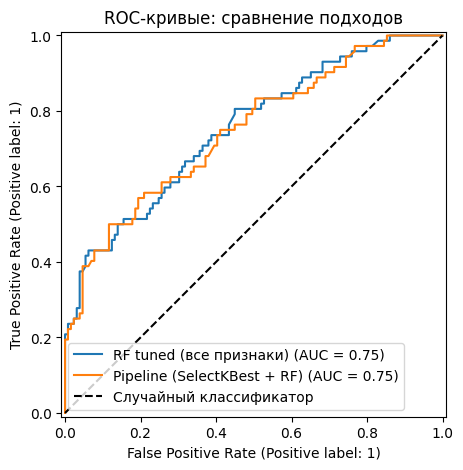

In [14]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(7, 5))

RocCurveDisplay.from_estimator(grid_rf, X_test, y_test, ax=ax, name='RF tuned (все признаки)')
RocCurveDisplay.from_estimator(grid_pipe, X_test, y_test, ax=ax, name='Pipeline (SelectKBest + RF)')

ax.plot([0, 1], [0, 1], 'k--', label='Случайный классификатор')
ax.set_title('ROC-кривые: сравнение подходов')
ax.legend()
plt.show()

In [ ]:
# grid_rf дал лучший ROC-AUC=0.752, берём его feature importances
importances = grid_rf.best_estimator_.feature_importances_
feat_names = X.columns
top_idx = np.argsort(importances)[::-1][:15]

plt.figure(figsize=(10, 5))
plt.bar(range(15), importances[top_idx])
plt.xticks(range(15), feat_names[top_idx], rotation=90)
plt.title('Топ-15 важных признаков (RF tuned, ROC-AUC=0.752)')
plt.tight_layout()
plt.show()

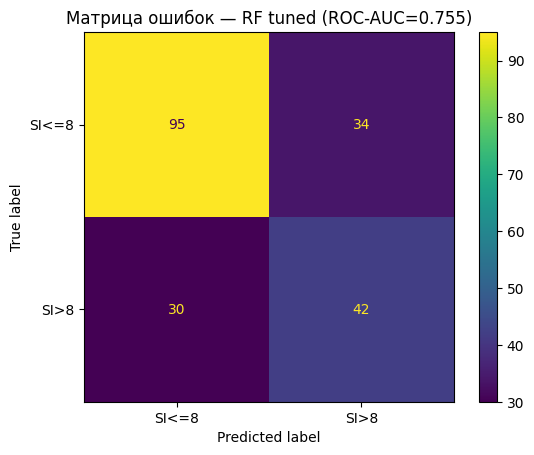

              precision    recall  f1-score   support

       SI<=8       0.76      0.74      0.75       129
        SI>8       0.55      0.58      0.57        72

    accuracy                           0.68       201
   macro avg       0.66      0.66      0.66       201
weighted avg       0.69      0.68      0.68       201



In [16]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

ConfusionMatrixDisplay.from_predictions(y_test, grid_rf.predict(X_test), display_labels=['SI<=8', 'SI>8'])
plt.title('Матрица ошибок — RF tuned (ROC-AUC=0.755)')
plt.show()

print(classification_report(y_test, grid_rf.predict(X_test), target_names=['SI<=8', 'SI>8']))

Задача SI > 8 сложнее медианного разбиения: классы несбалансированы, поэтому LogisticRegression без учёта баланса давала F1=0 по классу SI>8 (модель просто предсказывала всегда 0). После SMOTE ситуация исправилась.

Среди базовых моделей лучший ROC-AUC показали GradientBoosting (0.744) и RF (0.739). После тюнинга RF с GridSearchCV вырос до 0.752, что является лучшим результатом среди всех подходов. GB с RandomizedSearchCV дал 0.719. KNN (0.659) ожидаемо проиграл ансамблям: в пространстве 162 признаков евклидово расстояние теряет информативность.

Pipeline с оптимальным k=80 дал ROC-AUC=0.746 показал чуть хуже RF tuned на всех признаках (0.752), но зато модель прозрачнее: мы явно контролируем какие признаки входят, и GridSearchCV подбирает число признаков и гиперпараметры модели одновременно без утечки данных между фолдами.

Матрица ошибок подтверждает, что миноритарный класс (SI>8) распознаётся хуже, это ожидаемо даже после балансировки, поскольку SMOTE создаёт синтетические примеры, а не реальные данные. Для дальнейшего улучшения можно попробовать комбинирование SMOTE + Tomek links или увеличить штраф за ошибки на миноритарном классе через class_weight.